# EDA: PS3 Door subsystem

The task (`data/References/Door/Door_Subsystem_Info_Kit.md`) is **temporal segment
detection**: `Test.csv` is one continuous sensor stream running through many
door-open/close cycles back to back, and we have to find each cycle *and* label it
`Normal` or `Abnormal resistance`. Scoring is IoU-weighted F1, so timing errors and
label errors both cost, and spurious extra segments cost too.

This notebook works through the raw stream in four passes:

1. what's actually in the file,
2. whether cycle boundaries can be recovered (they can, exactly),
3. what one cycle looks like,
4. what, if anything, separates a normal cycle from an abnormal-resistance one.

Loading lives in [`ps3_data.py`](ps3_data.py), plotting in [`door_plots.py`](door_plots.py).
An earlier synthetic-fleet notebook (`door_events.pkl`, AI-generated) shared no schema
with this real data and was left behind in the old repository.

In [19]:
# Make the notebook runnable from any working directory (project root, PS3, or
# this folder). Jupyter sets the kernel's cwd from wherever it was launched, and
# `ps3_data` only imports if its folder is on sys.path -- so find it rather than
# assuming. Everything else in this notebook then goes through ps3_data, which
# resolves the dataset from its own location.
import pathlib
import sys

def _module_dir(filename="ps3_data.py"):
    start = pathlib.Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in [base, base / "Door subproblem", base / "PS3" / "Door subproblem"]:
            if (candidate / filename).is_file():
                return candidate
    raise FileNotFoundError(
        f"{filename} not found from {start} -- open the notebook from inside the "
        f"repository, or add its folder to sys.path manually.")

MODULE_DIR = _module_dir()
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))
print(f"modules: {MODULE_DIR}")


modules: C:\Users\keith\PycharmProjects\NebulaX-Hackathon-ProblemStatement\PS3\Door subproblem


In [20]:

import pandas as pd
import matplotlib.pyplot as plt

import ps3_data as ps3
import door_plots as dp

pd.set_option("display.width", 140)

stream, segments = ps3.load_door("Train")
test_stream, test_segments = ps3.load_door("Test")

print("train stream  ", stream.shape)
print("train segments", segments.shape)
print("test  stream  ", test_stream.shape)
print("test  segments", test_segments.shape)
segments.head()

STATUS_NORMAL_EDA = "Normal"


train stream   (18036, 22)
train segments (110, 11)
test  stream   (6253, 20)
test  segments (38, 7)


## 0. What's in this dataset

Three files, all under `data/Door/`:

| file | what it is |
|---|---|
| `Train.csv` | continuous stream, 18,036 readings, ~70 minutes of wall-clock time |
| `Train_Segments_Answer.csv` | ground truth: 110 cycles with start/end, operation and status |
| `Test.csv` | the held-out counterpart, 6,253 readings, **unlabelled** |

17 columns per reading: a timestamp plus 16 sensor channels.

**Analog channels** — where a resistance fault should physically show up:
`Motor current(mA)`, `Motor Voltage(10mV)`, `Motor electrodynamic force` (back-EMF),
`Door leaf position`.

**Command / switch flags** — binary state, useful as context rather than as fault evidence:
`Close command`, `Open command`, `DCSR`/`DCSL` (door close switch right/left),
`DLSR`/`DLSL` (door locked switch right/left), `Door Opened`, `Door Locked`,
`Door is opening`, `Door is closing`.

**Counters**: `Door opening time(.1s)`, `Door closing time(.1s)`.

Note the info kit's hint — *don't* assume the opening/closing flags are the best
segmentation signal. Section 1 tests what actually is.

In [21]:
# Facts computed from the data, not copied from the docs, so this stays honest
# if the files are ever reissued.
ans = ps3.load_door_answer()
span = stream["t"].max() - stream["t"].min()
covered = segments["n_rows"].sum()

print(f'''DOOR TRAIN AT A GLANCE
  readings             {len(stream):,}
  sensor channels      {len(ps3.DOOR_SENSOR_COLS)}
  wall-clock span      {span}
  within-cycle rate    {stream["dt"].median() * 1000:.0f} ms
  true cycles          {len(ans)}
  rows inside a cycle  {covered:,} of {len(stream):,}  ({covered / len(stream):.1%})
  status balance       {ans["status"].value_counts().to_dict()}
  operation balance    {ans["operation"].value_counts().to_dict()}
  cycle duration       {ans["n_rows"].min() * 0.02:.2f}-{ans["n_rows"].max() * 0.02:.2f} s
''')

DOOR TRAIN AT A GLANCE
  readings             18,036
  sensor channels      16
  wall-clock span      0 days 01:10:17.920000
  within-cycle rate    20 ms
  true cycles          110
  rows inside a cycle  18,036 of 18,036  (100.0%)
  status balance       {'Normal': 80, 'Abnormal resistance': 30}
  operation balance    {'Close': 55, 'Open': 55}
  cycle duration       2.74-3.80 s



Two things stand out immediately.

**Every row belongs to a cycle.** The rows covered by the 110 true segments sum to
exactly the row count of the file — there is no "idle" filler between cycles. The
stream is really a concatenation of cycle recordings with the dead time *dropped*,
not a continuous 70-minute recording. That's what makes section 1 work.

**Abnormal resistance is ~27% of cycles.** Imbalanced, but nowhere near as extreme
as the Rail subsystem. Worth remembering that a do-nothing model that calls
everything `Normal` still scores 80/110 = **0.727** under IoU-weighted F1, because
perfect segmentation alone earns the Normal cycles' IoU. That's the number to beat,
and it's a high floor.

## 1. Recovering the cycle boundaries

The kit frames segmentation as the hard half of the problem. It isn't — but the
reason it isn't is worth establishing rather than assuming.

Within a cycle the controller samples at a steady 20 ms. Between cycles, the
dropped dead time leaves a gap of seconds. If those two populations don't overlap,
a single gap threshold segments the stream exactly.

within-cycle gaps: max 0.911s   between-cycle gaps: min 10.215s
empty band between the two populations: 9.30s wide


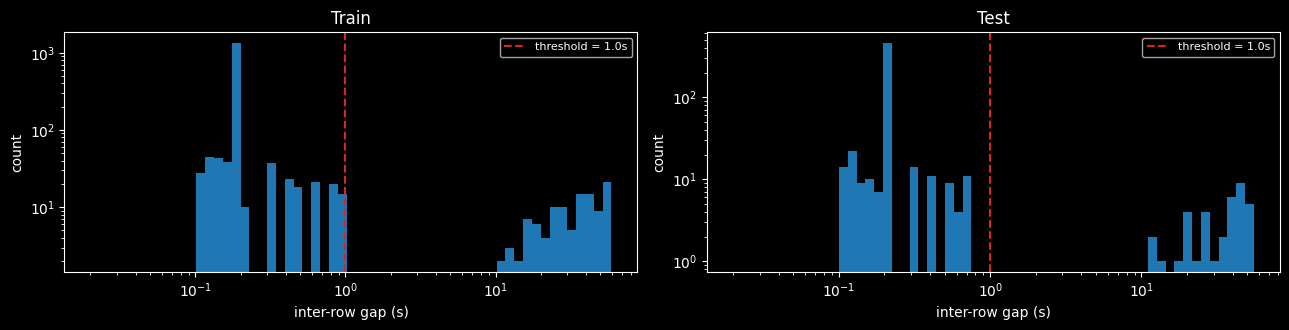

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
dp.plot_gap_distribution(stream, gap_seconds=ps3.DOOR_GAP_SECONDS, ax=axes[0])
axes[0].set_title("Train")
dp.plot_gap_distribution(test_stream, gap_seconds=ps3.DOOR_GAP_SECONDS, ax=axes[1])
axes[1].set_title("Test")
plt.tight_layout()

within = stream["dt"][(stream["dt"] > 0) & (stream["dt"] < 1)]
between = stream["dt"][stream["dt"] > 1]
print(f"within-cycle gaps: max {within.max():.3f}s   between-cycle gaps: min {between.min():.3f}s")
print(f"empty band between the two populations: {between.min() - within.max():.2f}s wide")

In [23]:
# The check that matters: does a 1s gap threshold reproduce the answer key exactly?
exact = {
    "segments found": (len(segments), len(ans)),
    "start_time exact": (segments["start_time"].values == ans["start_time"].values).all(),
    "end_time exact":   (segments["end_time"].values == ans["end_time"].values).all(),
    "n_rows exact":     (segments["n_rows"].values == ans["n_rows"].values).all(),
}
for k, v in exact.items():
    print(f"  {k:18} {v}")

# ...and what that is worth under the official metric, given perfect labels.
oracle = ps3.door_iou_f1(ans, segments)
print(f"\noracle score (our segmentation + true labels): {oracle['score']:.4f}")
print(f"all-Normal baseline:                           {ps3.door_iou_f1(ans, segments.assign(status='Normal'))['score']:.4f}")

  segments found     (110, 110)
  start_time exact   True
  end_time exact     True
  n_rows exact       True

oracle score (our segmentation + true labels): 1.0000
all-Normal baseline:                           0.7273


**Segmentation is solved, exactly.** All 110 cycles, all 220 boundaries, no false
splits — so the segmentation half of the score is a 1.0 and every remaining point
is a classification point. Two details keep it that way:

- The gap populations are separated by a wide empty band, so the 1 s threshold is
  not a tuned magic number — anything from roughly 1 s to 10 s gives the same answer.
- Timestamps are **not monotonic inside a cycle** (some rows run backwards by up to
  ~0.9 s). The answer key takes each cycle's first and last *row* positionally; using
  `min()`/`max()` of the timestamps instead disagrees on 9 of the 110 cycles. `ps3_data`
  follows the positional convention, which is why the boundaries match exactly.

One caveat worth stating: this is a property of how the organisers *built* the file.
If a future stream kept its dead time, this segmenter would emit one giant segment
and the score would collapse. A production version should fall back to the
command/switch flags. For this hackathon, the gap segmenter is correct and exact.

cycles per status/operation:
status     Abnormal resistance  Normal
operation                             
Close                       15      40
Open                        15      40


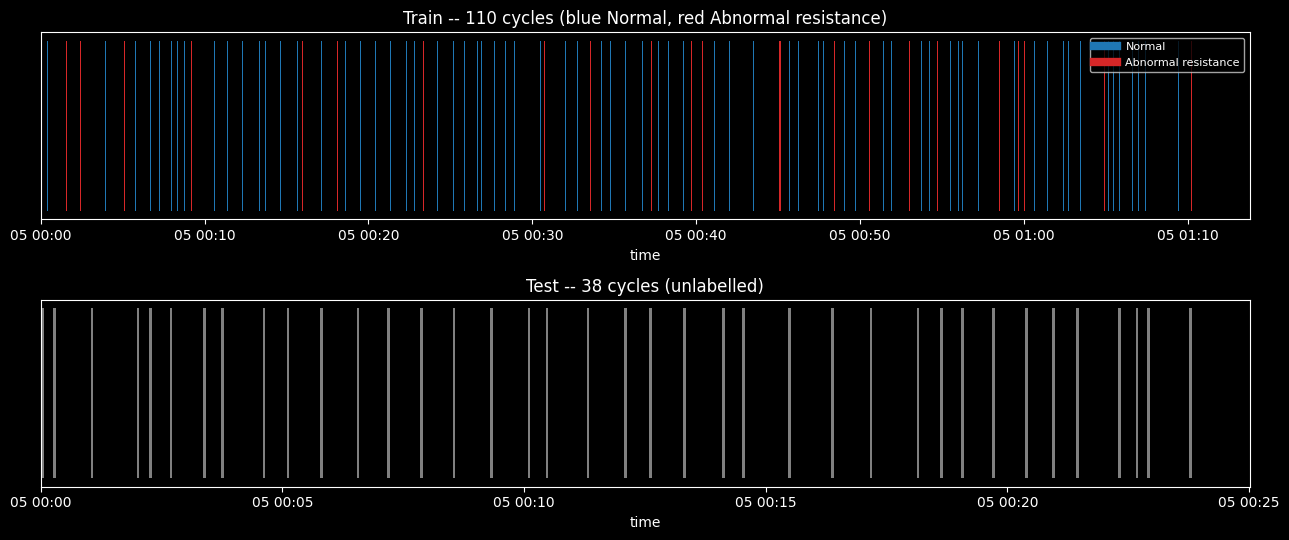

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5))
dp.plot_timeline(segments, ax=axes[0])
axes[0].set_title(f"Train -- {len(segments)} cycles (blue Normal, red Abnormal resistance)")
dp.plot_timeline(test_segments, ax=axes[1])
axes[1].set_title(f"Test -- {len(test_segments)} cycles (unlabelled)")
plt.tight_layout()

print("cycles per status/operation:")
print(pd.crosstab(segments["operation"], segments["status"]))

## 2. What one cycle looks like

Before any feature engineering, read a couple of cycles end to end. Open and Close
have different waveforms, so compare like with like throughout.

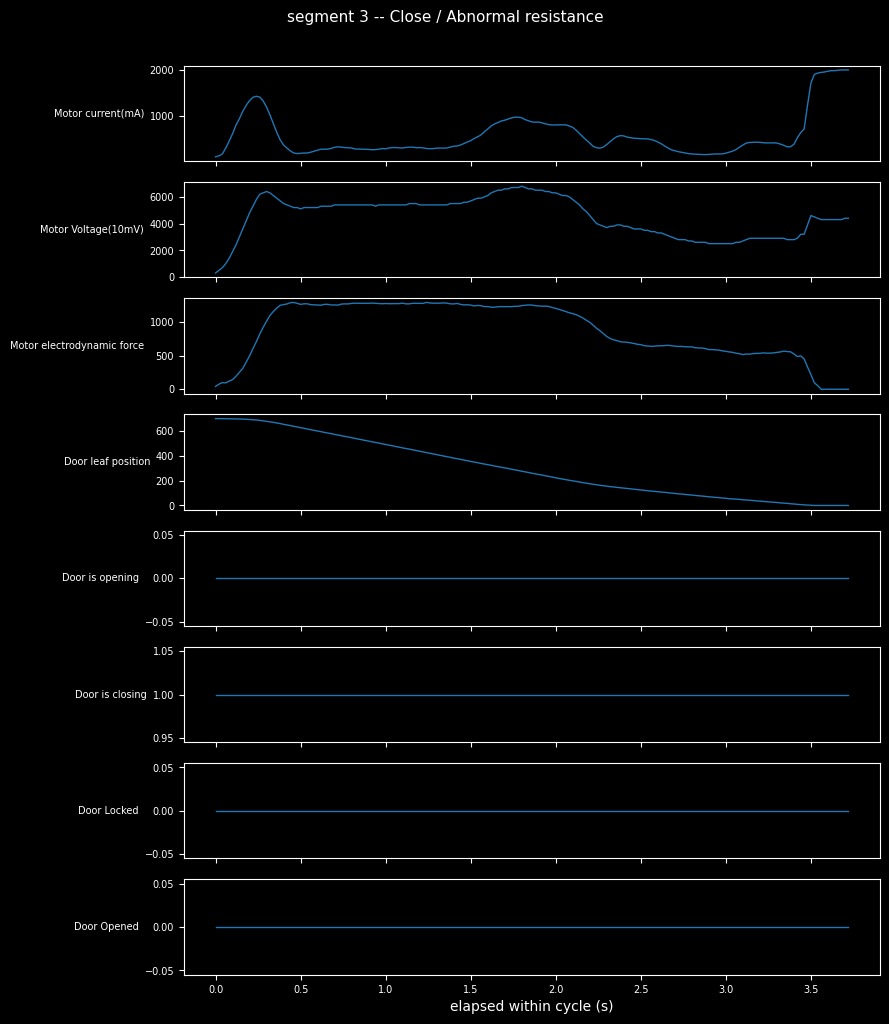

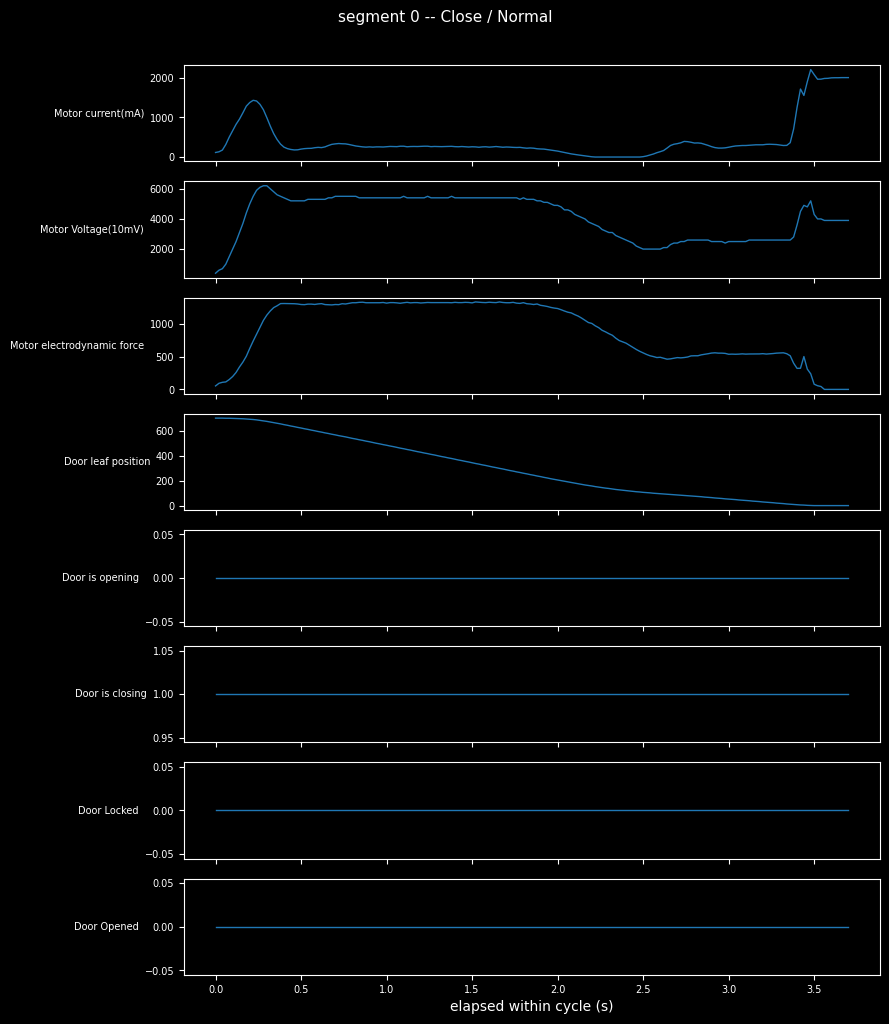

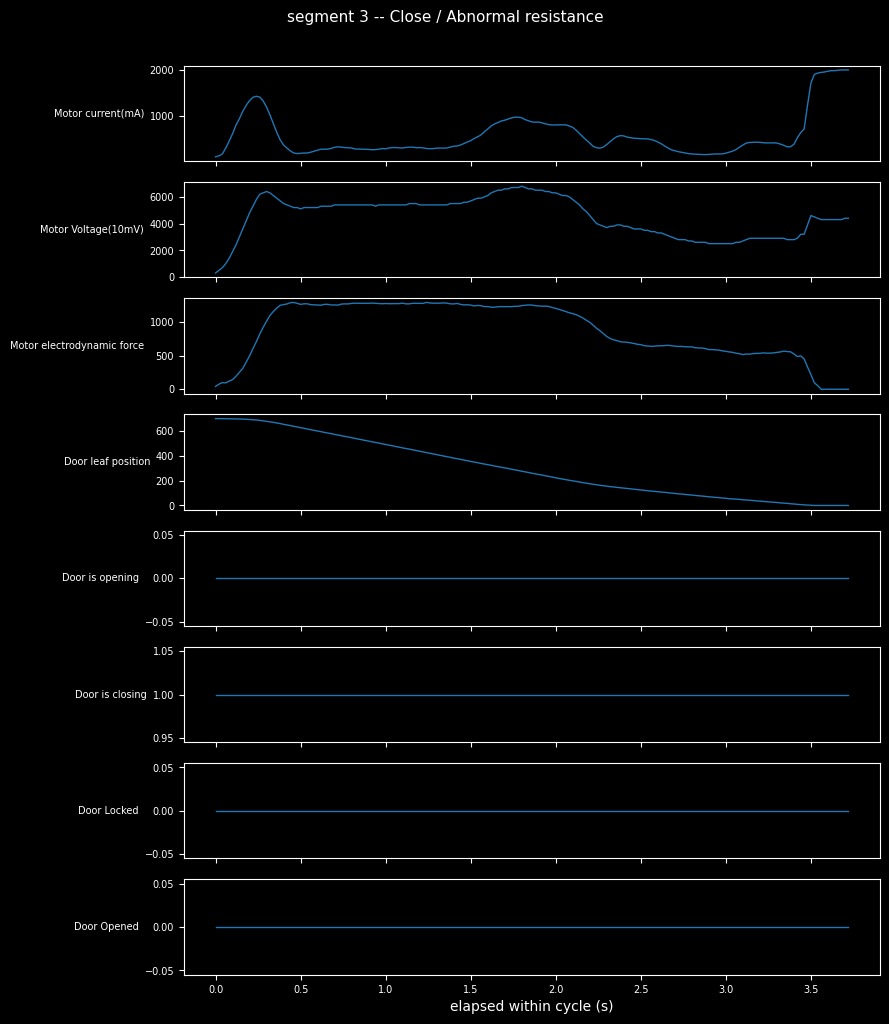

In [25]:
CHANNELS = ["Motor current(mA)", "Motor Voltage(10mV)", "Motor electrodynamic force",
            "Door leaf position", "Door is opening", "Door is closing",
            "Door Locked", "Door Opened"]

normal_close = segments.query("operation == 'Close' and status == 'Normal'").iloc[0]
abnormal_close = segments.query("operation == 'Close' and status == 'Abnormal resistance'").iloc[0]

dp.plot_cycle(stream, normal_close["segment"], CHANNELS, segments)
dp.plot_cycle(stream, abnormal_close["segment"], CHANNELS, segments)

## 3. Do the two statuses separate?

The overlay is the decisive plot: every cycle's trace for one channel on a shared
elapsed-time axis, coloured by status. If red and blue traces sit on top of each
other, no per-cycle summary statistic will save us and the classifier will need the
waveform shape. If they part company somewhere, that's the feature.

Run it both ways on the time axis — raw elapsed seconds, and normalised to each
cycle's own duration — since a resistance fault could plausibly show up as *slower*
travel, as *higher current at the same point*, or both.

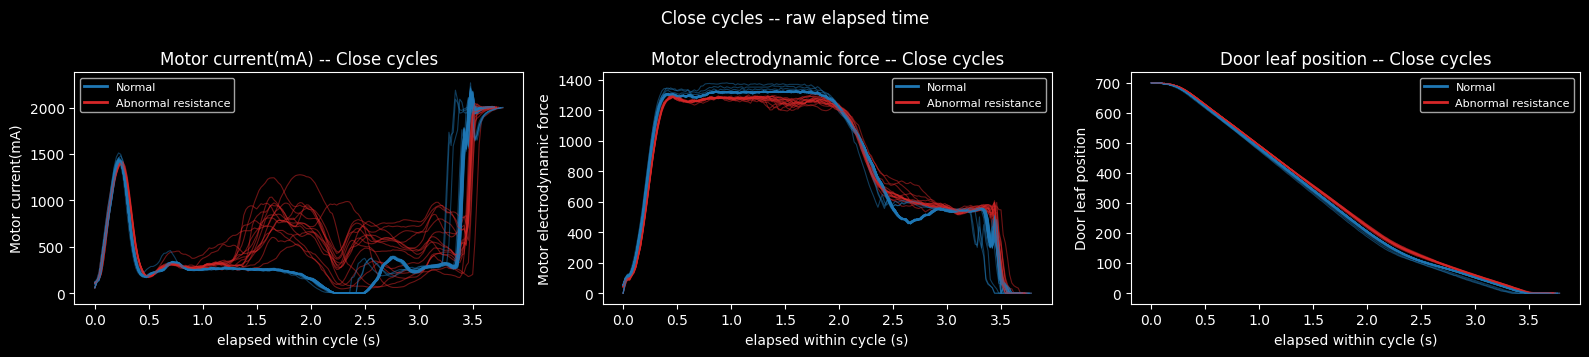

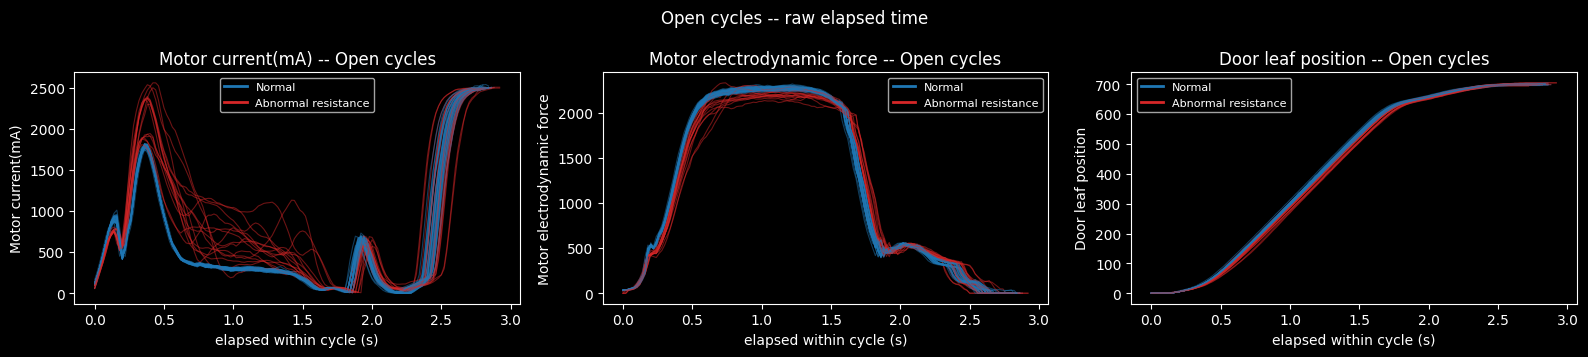

In [26]:
for operation in ["Close", "Open"]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
    for ax, channel in zip(axes, ["Motor current(mA)", "Motor electrodynamic force",
                                  "Door leaf position"]):
        dp.plot_cycle_overlay(stream, segments, channel, operation=operation, ax=ax)
    fig.suptitle(f"{operation} cycles -- raw elapsed time", fontsize=12)
    plt.tight_layout()

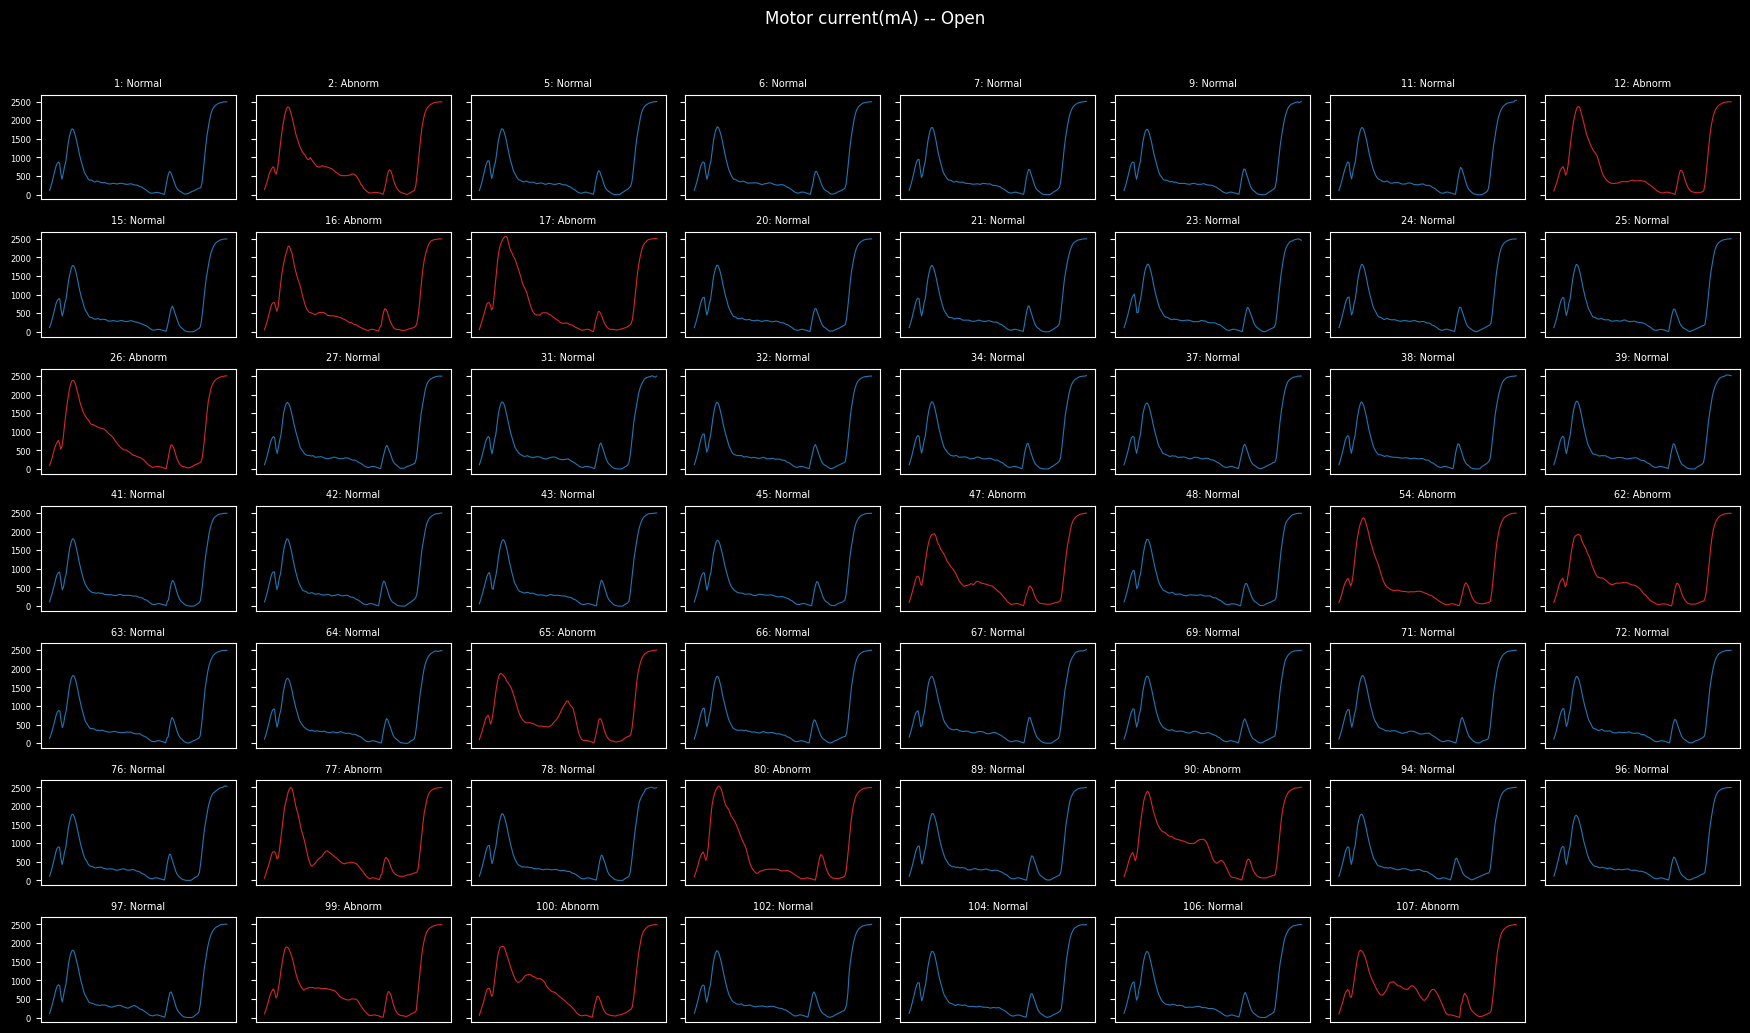

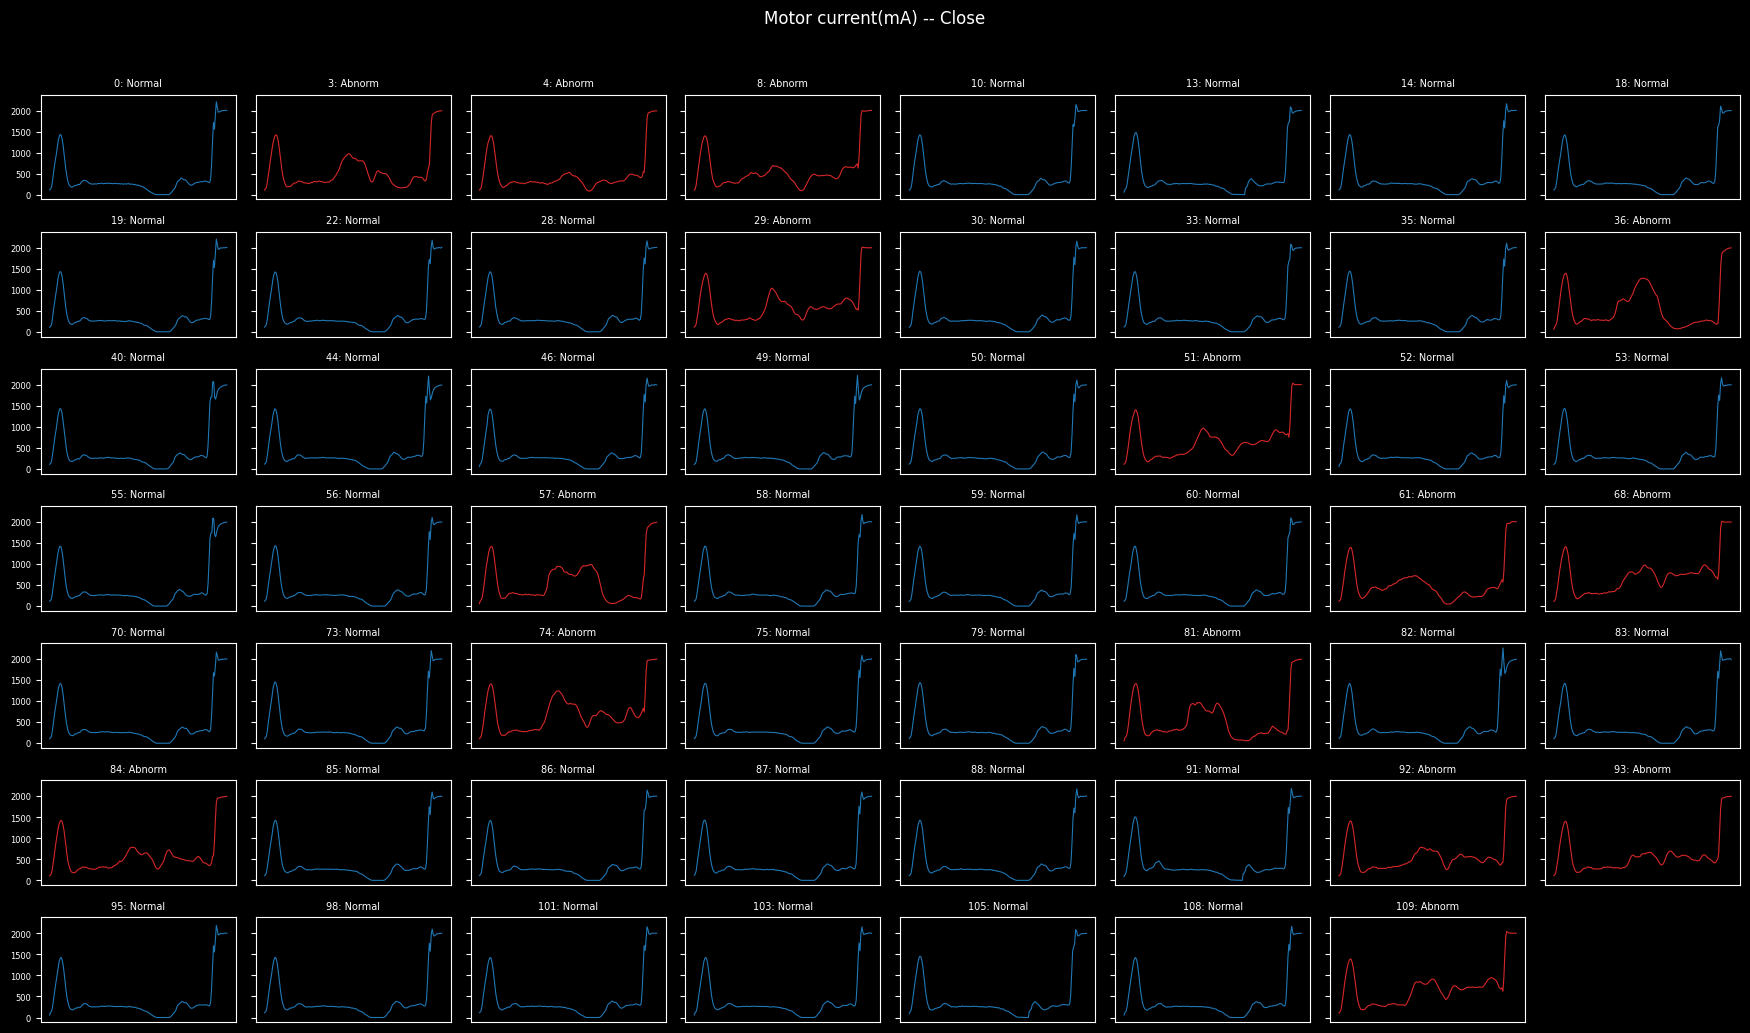

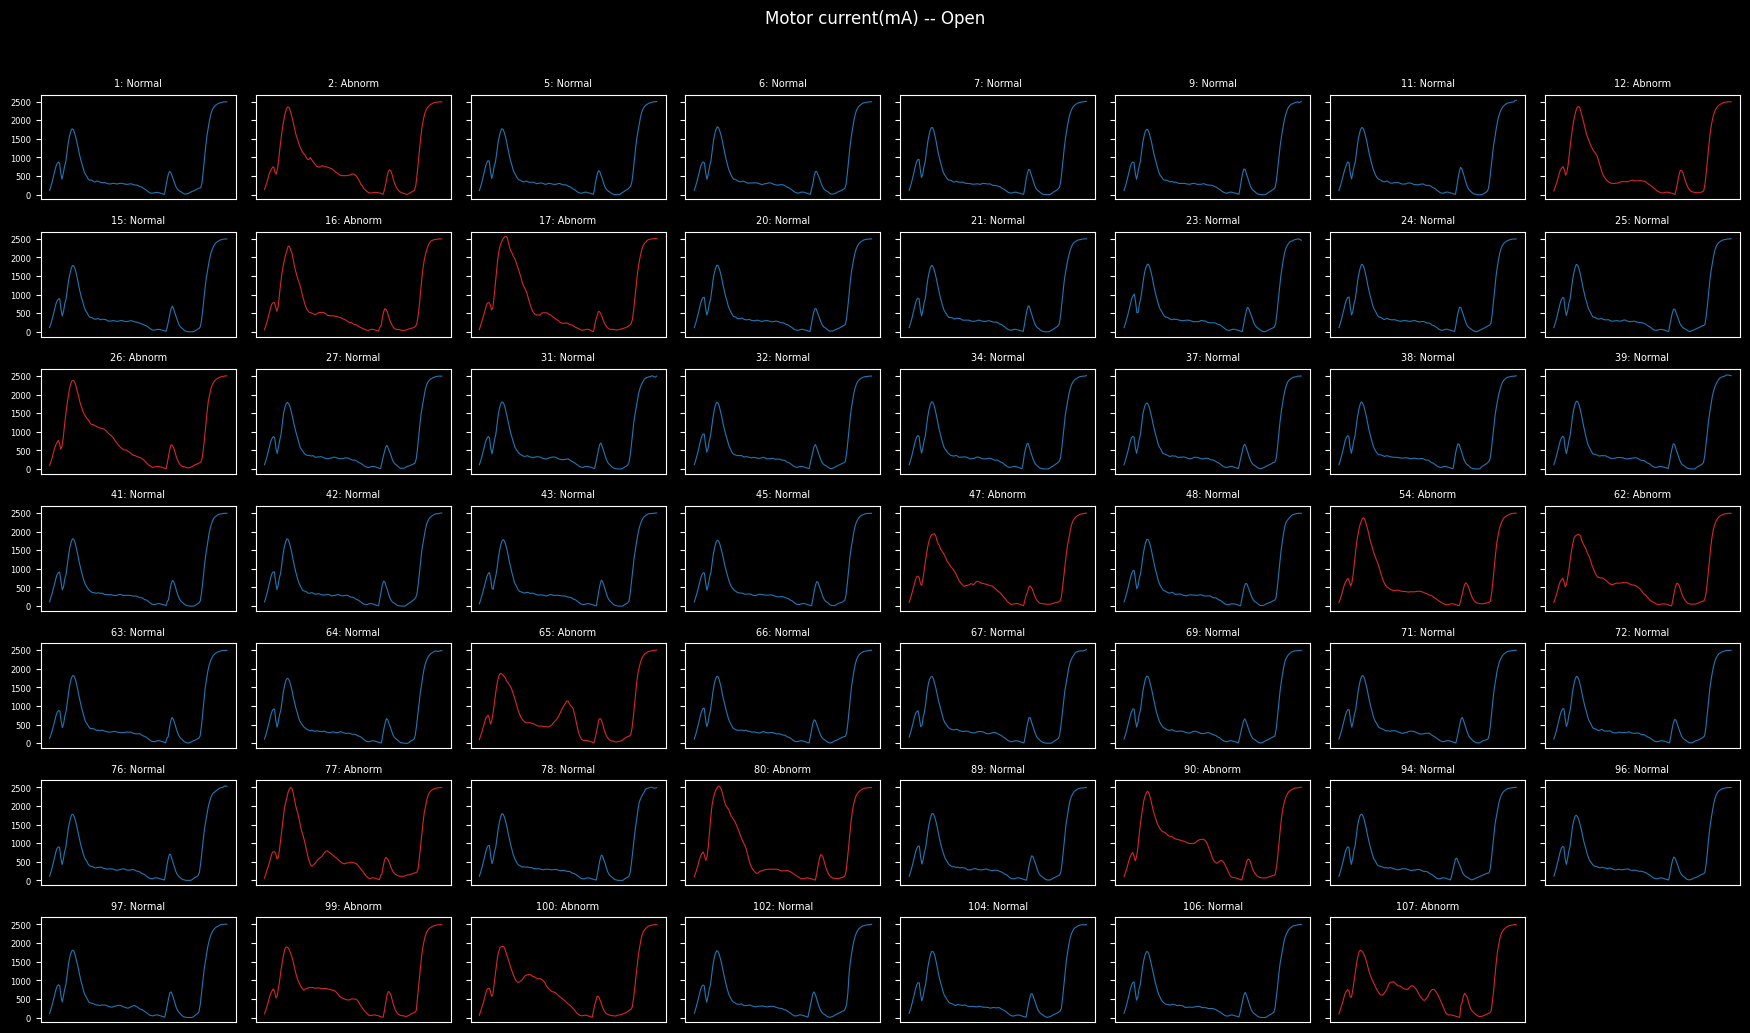

In [27]:
# Individual shapes, without 55 overlapping lines hiding them.
dp.plot_cycle_grid(stream, segments, "Motor current(mA)", operation="Close", ncols=8)
dp.plot_cycle_grid(stream, segments, "Motor current(mA)", operation="Open", ncols=8)

## 4. Which per-cycle statistics separate the statuses

Crude summary statistics per cycle (mean / max / min / std of each analog channel,
plus duration), ranked by Cohen's d between the two statuses. This is a shortlist,
not a feature set — it says where to look, and it says whether a simple tabular
classifier is even viable before we reach for anything sequence-shaped.

In [28]:
summary = dp.cycle_summary(stream, segments, ps3.DOOR_ANALOG_COLS)
print(summary.shape)

for operation in ["Close", "Open"]:
    print(f"\n=== {operation}: top separating statistics ===")
    print(dp.separation_ranking(summary, operation=operation).head(10).to_string(index=False))

(110, 21)

=== Close: top separating statistics ===
                       feature  cohens_d  normal_mean  abnormal_mean
Motor electrodynamic force|std  6.068379   444.324041     416.534413
         Motor current(mA)|min  5.207782     0.000000      92.866667
Motor electrodynamic force|max  4.142107  1331.000000    1297.600000
         Motor current(mA)|max  4.040582  2147.825000    2006.266667
      Motor Voltage(10mV)|mean  3.817492  4142.963364    4603.078084
        Motor current(mA)|mean  3.707073   428.084149     614.967180
       Door leaf position|mean  3.683321   293.202410     300.792289
         Motor current(mA)|std  3.401751   519.107902     452.473417
       Motor Voltage(10mV)|max  1.982388  6217.500000    6686.666667
        Door leaf position|std  1.864345   235.352861     234.347408

=== Open: top separating statistics ===
                        feature  cohens_d  normal_mean  abnormal_mean
        Motor Voltage(10mV)|max  7.050741  9177.500000   10320.000000
        

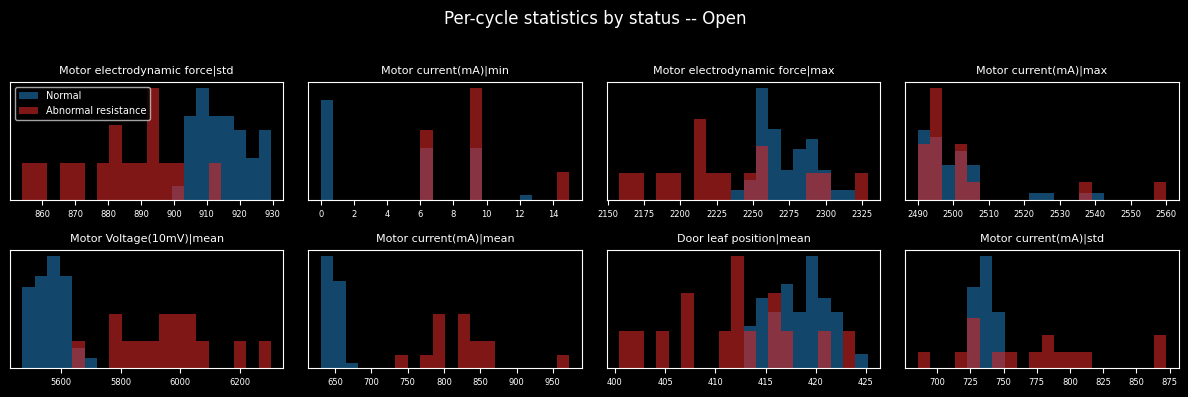

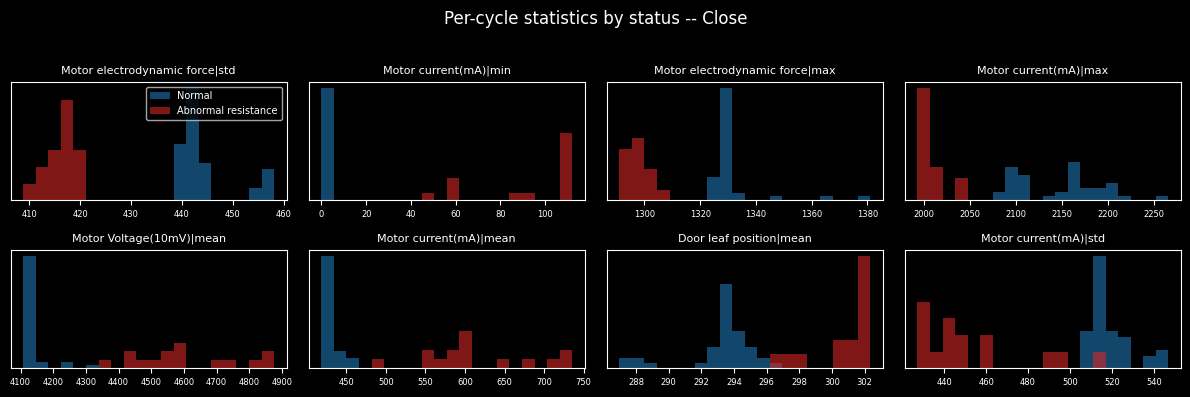

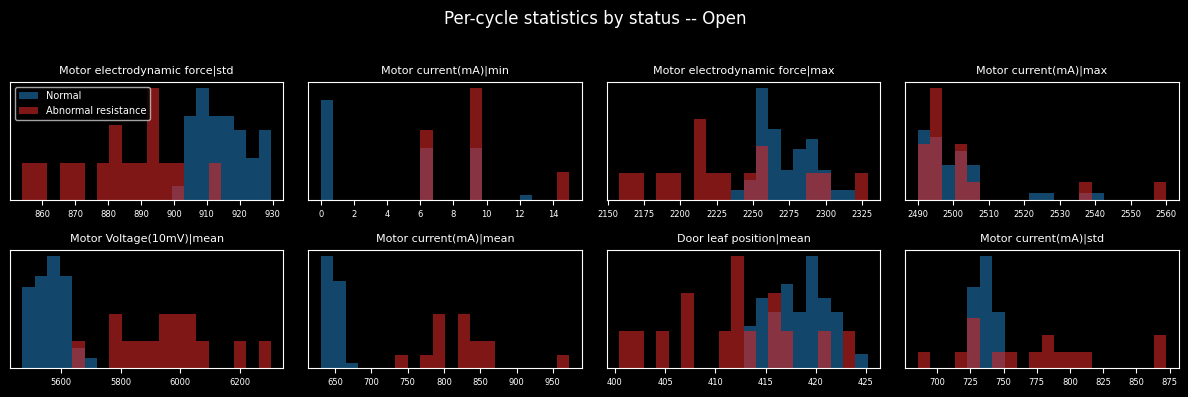

In [29]:
# Plot the strongest handful for Close cycles, and the same columns for Open, so the
# two operations can be compared directly.
top_close = dp.separation_ranking(summary, operation="Close")["feature"].head(8).tolist()
dp.plot_status_distributions(summary, columns=top_close, operation="Close")
dp.plot_status_distributions(summary, columns=top_close, operation="Open")

### 4b. How separable is it, really?

The Cohen's d values above are enormous (5-7 where 0.8 is conventionally "large"),
which is worth taking seriously rather than celebrating. Check the actual ranges.

In [30]:
for operation, feature in [("Close", "Motor current(mA)|min"),
                           ("Open", "Motor Voltage(10mV)|max")]:
    sub = summary[summary["operation"] == operation]
    normal = sub.loc[sub["status"] == "Normal", feature]
    abnormal = sub.loc[sub["status"] == "Abnormal resistance", feature]
    print(f"{operation:6} {feature:24}  normal [{normal.min():.0f}, {normal.max():.0f}]"
          f"   abnormal [{abnormal.min():.0f}, {abnormal.max():.0f}]"
          f"   overlap: {normal.max() >= abnormal.min()}")

Close  Motor current(mA)|min     normal [0, 0]   abnormal [47, 112]   overlap: False
Open   Motor Voltage(10mV)|max   normal [9000, 9300]   abnormal [9800, 10500]   overlap: False


**One statistic per operation separates the two classes perfectly on Train.** For
Close cycles the motor current returns to exactly 0 mA at some point in every normal
cycle and never drops below 47 mA in any abnormal one — physically sensible, a jammed
door keeps drawing holding current. For Open cycles the peak motor voltage is capped
around 9,300 in normal cycles and starts at 9,800 in abnormal ones.

Treat this as a warning as much as a result. Clean, gapped, physically-tidy
separation on all 110 training cycles usually means the fault was *injected* with a
consistent rule rather than observed in the wild. Two consequences:

- A hand-tuned threshold on one feature would score 1.0 on Train and tells us almost
  nothing about Test. Cross-validation will also report ~1.0 and likewise tell us
  nothing — with perfectly separable classes, every fold is perfect.
- The safe play is a model that uses *several* correlated statistics rather than the
  single sharpest one, so that if Test shifts the decision boundary a little, the
  prediction degrades gracefully instead of flipping wholesale. A small regularised
  model (logistic regression or a shallow gradient-boosted tree) on the per-operation
  summary table is the right size of hammer here — a sequence model has nothing left
  to learn that these statistics haven't already captured.

The honest headline: on this data the Door task is *easy*, and the risk is not
underfitting but over-trusting a boundary fitted to 110 tidy cycles.

## 5. All 16 channels, not just the analog four

Sections 2-4 looked at the four continuously-varying channels, on the assumption
that a mechanical resistance fault shows up in the motor signals. That assumption
is worth testing rather than trusting — the switch and command flags carry the
door's *state machine*, and a jam could plausibly show up as a switch actuating
late, a command being reasserted, or the controller's own opening/closing time
counters landing on a different value.

This section sweeps every channel so nothing is excluded by assumption.

In [31]:
ALL_CHANNELS = ps3.DOOR_SENSOR_COLS
print(f"{len(ALL_CHANNELS)} channels")

# Which ones are constant across the whole stream, and therefore carry nothing?
spread = stream[ALL_CHANNELS].std()
constant = spread[spread == 0].index.tolist()
varying = [c for c in ALL_CHANNELS if c not in constant]
print(f"constant across the whole file: {constant}")
print(f"varying: {len(varying)}")

# How many distinct values does each take? Separates true analog channels from
# flags and from counters, without hardcoding which is which.
distinct = stream[varying].nunique().sort_values(ascending=False)
print()
print(distinct.to_string())

16 channels
constant across the whole file: ['Door Locked']
varying: 15

Motor electrodynamic force    1962
Motor current(mA)              845
Door leaf position             706
Motor Voltage(10mV)            104
Door closing time(.1s)           5
Door opening time(.1s)           3
Close command                    2
Open command                     2
DCSR                             2
DLSR                             2
DCSL                             2
DLSL                             2
Door Opened                      2
Door is opening                  2
Door is closing                  2


### 5.1 Every channel overlaid, Close cycles

Same overlay as section 3 but for all channels at once. Red is Abnormal
resistance, blue Normal. Look for any channel where red departs from the blue
envelope — that's a candidate the analog-only view would have missed.

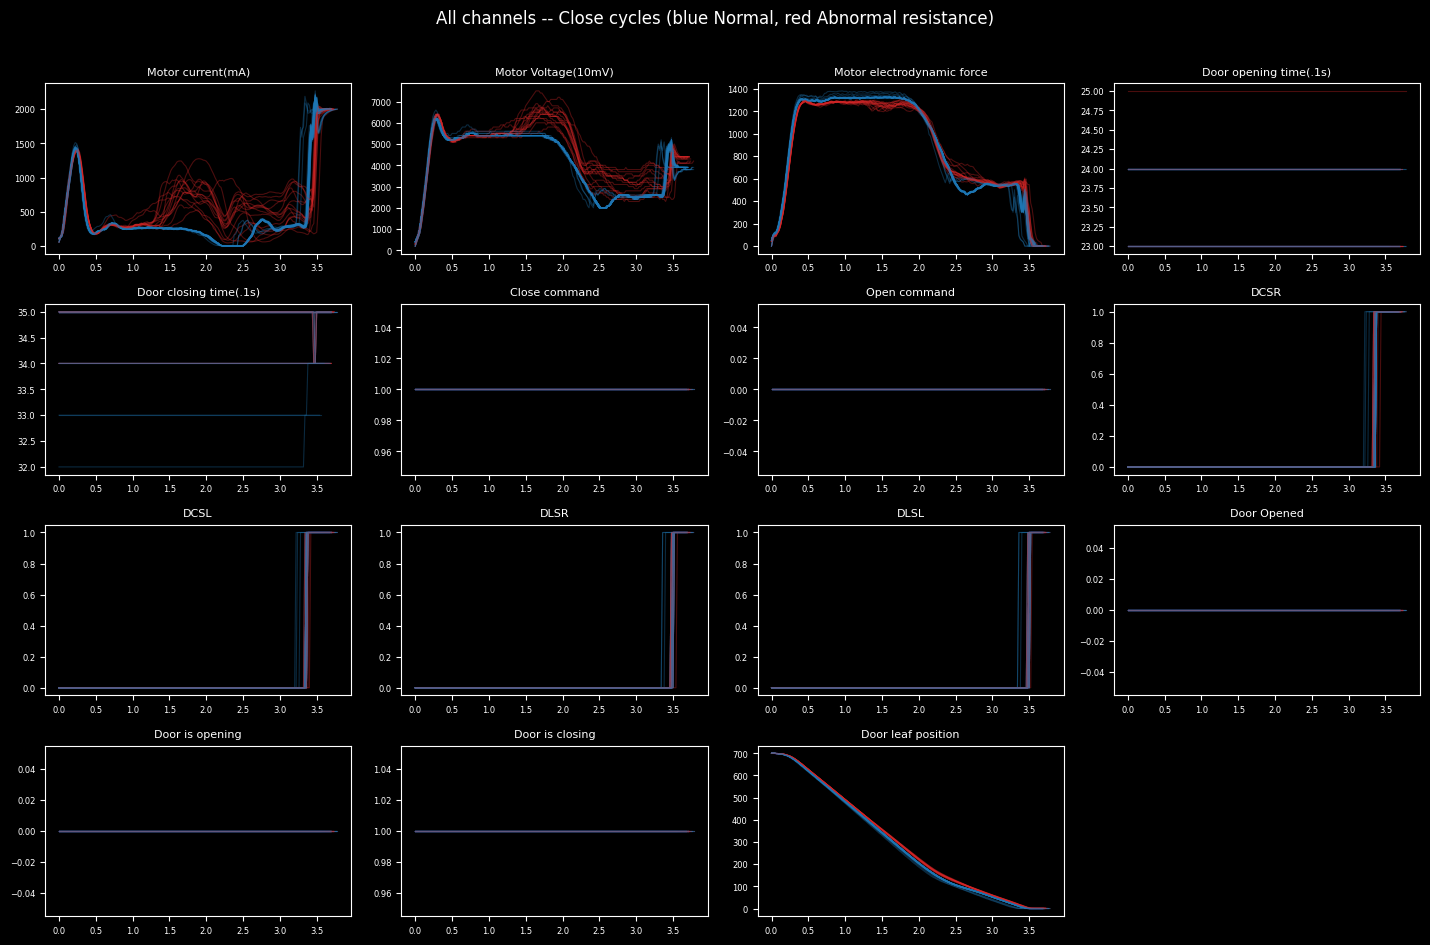

In [32]:
def overlay_all(operation, channels=None, ncols=4, cell=(3.6, 2.4)):
    channels = channels or varying
    nrows = math.ceil(len(channels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell[0] * ncols, cell[1] * nrows),
                             squeeze=False)
    for ax, channel in zip(axes.flatten(), channels):
        dp.plot_cycle_overlay(stream, segments, channel, operation=operation, ax=ax,
                              alpha=0.35)
        ax.set_title(channel, fontsize=8)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.tick_params(labelsize=6)
        if ax.get_legend():
            ax.get_legend().remove()
    for ax in axes.flatten()[len(channels):]:
        ax.axis("off")
    fig.suptitle(f"All channels -- {operation} cycles "
                 f"(blue Normal, red Abnormal resistance)", fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    return fig


import math
overlay_all("Close")
plt.show()

### 5.2 Every channel overlaid, Open cycles

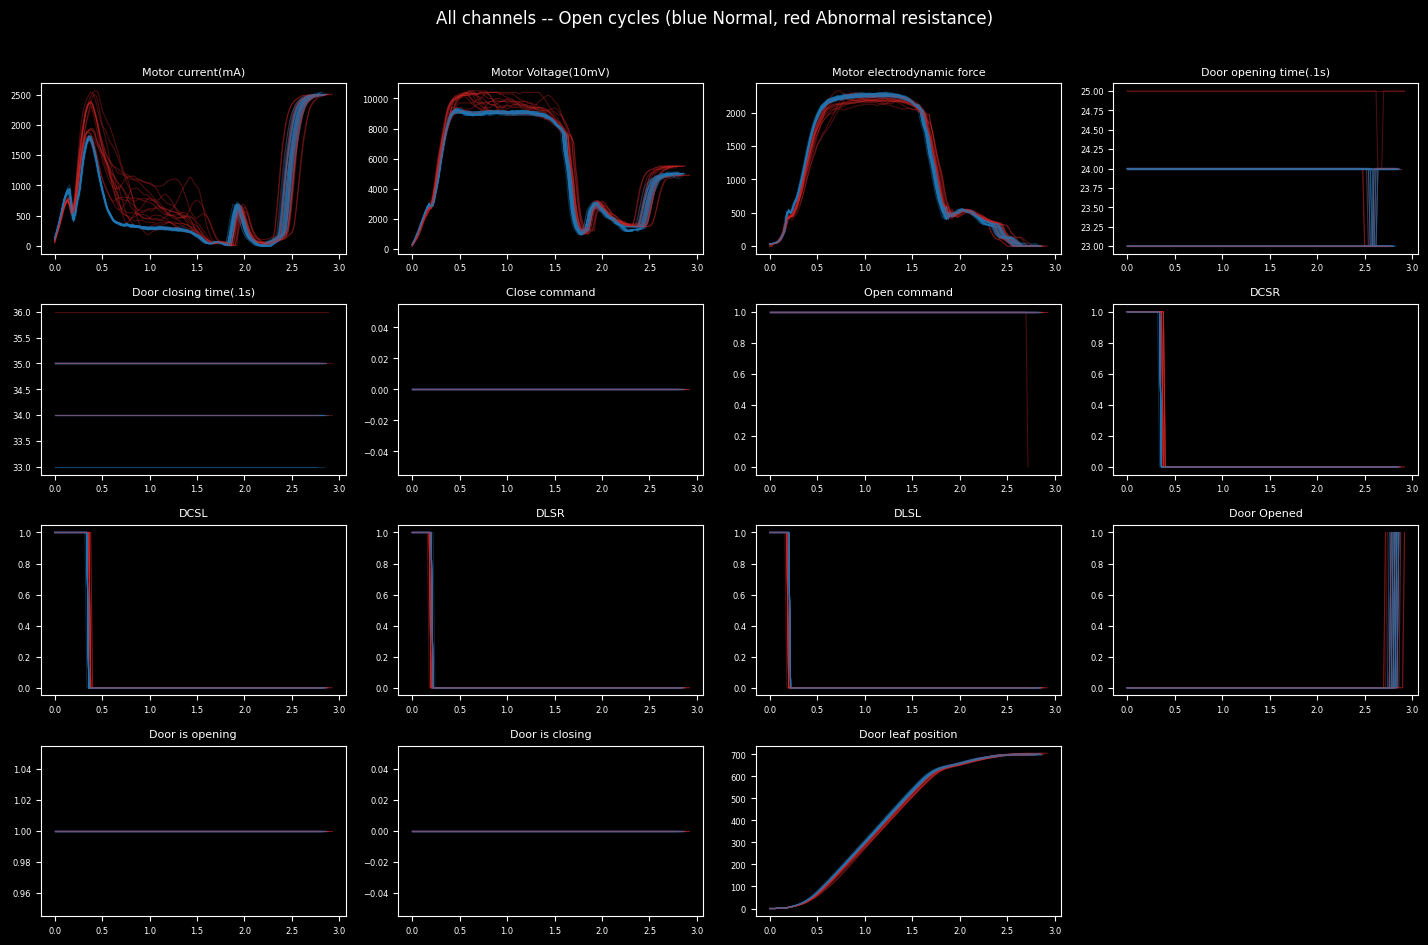

In [33]:
overlay_all("Open")
plt.show()

### 5.3 Ranking all 16 channels

`cycle_summary` over every channel rather than the analog four, ranked by Cohen's
d. If a flag or counter channel appears near the top, it belongs in the model; if
they all sit near zero, the analog-only choice was justified rather than lucky.

In [34]:
summary_all = dp.cycle_summary(stream, segments, varying)

for operation in ["Close", "Open"]:
    ranked = dp.separation_ranking(summary_all, operation=operation)
    ranked["channel"] = ranked["feature"].str.split("|").str[0]
    print(f"\n=== {operation}: top 15 of {len(ranked)} statistics ===")
    print(ranked.head(15)[["feature", "cohens_d", "normal_mean", "abnormal_mean"]]
          .to_string(index=False))

    # best statistic per channel, so one loud channel can't fill the table
    best = (ranked.sort_values("cohens_d", ascending=False)
                  .groupby("channel", as_index=False).first()
                  .sort_values("cohens_d", ascending=False))
    print(f"\n--- {operation}: best statistic per channel ---")
    print(best[["channel", "feature", "cohens_d"]].to_string(index=False))


=== Close: top 15 of 31 statistics ===
                        feature  cohens_d  normal_mean  abnormal_mean
 Motor electrodynamic force|std  6.068379   444.324041     416.534413
          Motor current(mA)|min  5.207782     0.000000      92.866667
 Motor electrodynamic force|max  4.142107  1331.000000    1297.600000
          Motor current(mA)|max  4.040582  2147.825000    2006.266667
       Motor Voltage(10mV)|mean  3.817492  4142.963364    4603.078084
         Motor current(mA)|mean  3.707073   428.084149     614.967180
        Door leaf position|mean  3.683321   293.202410     300.792289
          Motor current(mA)|std  3.401751   519.107902     452.473417
        Motor Voltage(10mV)|max  1.982388  6217.500000    6686.666667
         Door leaf position|std  1.864345   235.352861     234.347408
Motor electrodynamic force|mean  1.685174   893.378050     879.375907
         Door leaf position|min  1.527525     0.000000       0.666667
        Motor Voltage(10mV)|min  1.232647   365.00

In [35]:
# Do any non-analog channels separate the classes on their own? Perfect
# separation (no overlap between the two classes' ranges) is the strongest
# possible evidence a channel carries signal.
rows = []
for operation in ["Close", "Open"]:
    sel = summary_all[summary_all["operation"] == operation]
    for column in sel.columns:
        if "|" not in column:
            continue
        normal = sel.loc[sel["status"] == STATUS_NORMAL_EDA, column].dropna()
        abnormal = sel.loc[sel["status"] != STATUS_NORMAL_EDA, column].dropna()
        if len(normal) < 2 or len(abnormal) < 2:
            continue
        separated = normal.max() < abnormal.min() or abnormal.max() < normal.min()
        if separated:
            rows.append({"operation": operation, "feature": column,
                         "normal_range": f"[{normal.min():.6g}, {normal.max():.6g}]",
                         "abnormal_range": f"[{abnormal.min():.6g}, {abnormal.max():.6g}]"})

perfect = pd.DataFrame(rows)
print(f"{len(perfect)} statistics separate the classes with no overlap at all:")
print(perfect.to_string(index=False) if len(perfect) else "  (none)")

10 statistics separate the classes with no overlap at all:
operation                        feature       normal_range     abnormal_range
    Close         Motor current(mA)|mean   [418.597, 456.2] [484.548, 735.406]
    Close          Motor current(mA)|max       [2078, 2266]       [1993, 2046]
    Close          Motor current(mA)|min             [0, 0]          [47, 112]
    Close       Motor Voltage(10mV)|mean  [4108.6, 4304.49] [4339.25, 4875.81]
    Close Motor electrodynamic force|max       [1324, 1381]       [1291, 1307]
    Close Motor electrodynamic force|std [438.441, 458.135] [408.834, 420.904]
    Close        Door leaf position|mean [286.989, 296.469] [296.738, 302.333]
     Open         Motor current(mA)|mean [630.278, 666.468] [738.299, 972.812]
     Open        Motor Voltage(10mV)|max       [9000, 9300]      [9800, 10500]
     Open        Motor Voltage(10mV)|std [3147.92, 3261.55] [3295.96, 3679.11]


### 5.4 What to take from this

Read the ranking before deciding what the model gets. Three possible outcomes,
each pointing somewhere different:

- **Only the motor channels rank** — the two-channel profile model is justified,
  and the flags are context rather than evidence.
- **A switch or counter channel ranks high too** — add it to `PROFILE_COLS` in the
  sequence-model notebook. Note that flags are step functions, so an IQR band
  around them behaves differently from one around a smooth signal: where every
  normal cycle agrees the IQR is 0 and the floor takes over, which is exactly the
  `IQR_FLOOR_FRAC` sensitivity already flagged there.
- **A counter like `Door opening time(.1s)` separates perfectly** — that would be
  the controller telling you its own verdict, and worth treating with suspicion:
  it may be a derived diagnostic rather than an independent measurement, which
  would make it a leak rather than a feature.

## Where this leaves the modelling

Reading off the sections above:

- **Segmentation contributes nothing further.** It is exact on Train and the Test
  stream has the same gap structure (38 cycles). Effort spent here has no upside;
  all remaining score is in the label.
- **The bar is 0.727**, not 0. Predicting `Normal` everywhere already scores that,
  so a classifier only helps if it catches abnormal cycles without misfiring on
  normal ones — and under this metric a false positive costs *twice*, once as a
  wrong-label prediction that cannot match and once as the true Normal cycle it
  fails to claim. Precision matters more here than the raw class balance suggests.
- **Split by operation, or feed operation as a feature.** Open and Close waveforms
  differ more from each other than the statuses do within either, and operation is
  derivable at inference time from the command flags — it is *not* a label we'd be
  leaking.
- **Validation:** hold out whole cycles, stratified by (operation, status), and score
  with `ps3.door_iou_f1` on the held-out slice rather than with plain accuracy, so the
  number we tune against is the number the judges compute. Expect it to read ~1.0
  given section 4b — which makes it a leakage check and a pipeline check, not a model
  selection signal. Fit the scaler inside the fold, on training cycles only, so that
  stays true.
- **Prefer the robust model over the sharpest one.** Since validation can't rank
  models here, pick on generalisation reasoning instead: several correlated features,
  regularised, per operation.